In [1]:
import scanpy as sc
import torch
from matplotlib import pyplot as plt
import numpy as np

from src.models.destvi import DestVI
from src.models.condscvi import CondSCVI

# from src.utils.ContrasiveDataLoader import ContrastiveAnnDataLoader


sc_adata = sc.read_h5ad("../data/simulation_Mouse_Kidney_MERFISH/MERFISH_kidney_object.h5ad")
st_adata = sc.read_h5ad("../data/simulation_Mouse_Kidney_MERFISH/MK_simulated_ST.h5ad")
print(sc_adata)
print(st_adata)

/home/pxy/miniconda3/envs/destvi/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 126547 × 307
    obs: 'fov', 'volume', 'center_x', 'center_y', 'min_x', 'min_y', 'max_x', 'max_y', 'barcodeCount', 'average_DAPI_score', 'area', 'n_counts', 'leiden', 'free_annotation'
    uns: 'free_annotation_colors', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'
AnnData object with n_obs × n_vars = 1520 × 307
    obs: 'spot_id', 'n_cells'
    uns: 'cell_types'
    obsm: 'spatial', 'true_proportion'


In [2]:
CondSCVI.setup_anndata(sc_adata, layer="counts", labels_key="free_annotation")

In [3]:
# 训练CondSCVI
sc_model = CondSCVI(sc_adata, weight_obs=False)
sc_model.view_anndata_setup()

Anndata setup with scvi-tools version 1.3.3.

Setup via `CondSCVI.setup_anndata` with arguments:

{'labels_key': 'free_annotation', 'layer': 'counts', 'batch_key': None}

     Summary Statistics      
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃ Summary Stat Key ┃ Value  ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│     n_batch      │   1    │
│     n_cells      │ 126547 │
│     n_labels     │   8    │
│      n_vars      │  307   │
└──────────────────┴────────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │  adata.layers['counts']   │
│    batch     │ adata.obs['_scvi_batch']  │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                                         labels State Registry                                          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃       Source Location        ┃                   Categories                    ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['free_annotation'] │                endothelial cell                 │          0          │
│                              │       epithelial cell of proximal tubule        │          1          │
│                              │     kidney collecting duct epithelial cell      │          2          │
│                              │ kidney distal convoluted tubule epithelial cell │          3          │
│                              │      kidney loop of Henle epithelial cell       │          4          │
│                              │                    podocyte                     │          5          │
│                              │                   immune cell                   │          6          │
│                              │                    pericyte                     │          7          │
└──────────────────────────────┴─────────────────────────────────────────────────┴─────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_batch'] │     0      │          0          │
└──────────────────────────┴────────────┴─────────────────────┘

In [4]:
# callback = PrintLossCallback(print_every_n_epochs=10)
# sc_model.train(callbacks=[callback])
sc_model.train(max_epochs=300)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/pxy/miniconda3/envs/destvi/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Epoch 1/300:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 300/300: 100%|██████████| 300/300 [1:00:00<00:00, 11.96s/it, v_num=1, train_loss_step=158, train_loss_epoch=149]

`Trainer.fit` stopped: `max_epochs=300` reached.


Epoch 300/300: 100%|██████████| 300/300 [1:00:00<00:00, 12.00s/it, v_num=1, train_loss_step=158, train_loss_epoch=149]


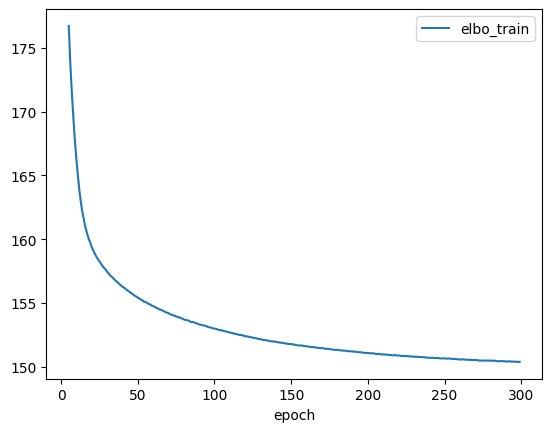

In [5]:
sc_model.history["elbo_train"].iloc[5:].plot()
plt.show()

In [6]:
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def build_hybrid_graph(adata, spatial_k=6, expr_k=10, spatial_weight=0.4, expr_weight=0.6, spatial_key="spatial"):
    """
    构建混合图：空间邻接图 + 表达相似性图
    
    Parameters:
    - spatial_k: 空间邻接的 k 值
    - expr_k: 表达相似性的 k 值  
    - spatial_weight: 空间邻接权重
    - expr_weight: 表达相似性权重
    """
    coords = adata.obsm[spatial_key]
    X = adata.X.toarray() if hasattr(adata.X, 'toarray') else adata.X
    n_spots = coords.shape[0]
    
    print(f"构建混合图: spatial_k={spatial_k}, expr_k={expr_k}, weights=({spatial_weight:.2f}, {expr_weight:.2f})")
    
    # 1. 空间邻接图
    spatial_nbrs = NearestNeighbors(n_neighbors=min(spatial_k + 1, n_spots)).fit(coords)
    _, spatial_indices = spatial_nbrs.kneighbors(coords)
    
    spatial_edges = []
    spatial_weights = []
    for i in range(n_spots):
        for j in spatial_indices[i, 1:]:  # 去掉自己
            spatial_edges.append([i, j])
            spatial_weights.append(spatial_weight)
    
    # 2. 表达相似性图
    # 使用 cosine 相似性，只保留高相似性的边
    print("计算表达相似性...")
    expr_sim = cosine_similarity(X)
    np.fill_diagonal(expr_sim, 0)  # 去掉自相似性
    
    # 对每个节点保留 top-k 最相似的邻居
    expr_edges = []
    expr_weights = []
    for i in range(n_spots):
        # 找到 top-k 相似的邻居
        sim_scores = expr_sim[i]
        top_k_idx = np.argpartition(sim_scores, -expr_k)[-expr_k:]
        top_k_idx = top_k_idx[sim_scores[top_k_idx] > 0.1]  # 过滤低相似性
        
        for j in top_k_idx:
            if i != j:
                expr_edges.append([i, j])
                # 将相似性转换为权重
                expr_weights.append(expr_weight * sim_scores[j])
    
    # 3. 合并边和权重
    all_edges = spatial_edges + expr_edges
    all_weights = spatial_weights + expr_weights
    
    # 转换为 tensor
    if len(all_edges) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_weight = torch.empty(0, dtype=torch.float)
    else:
        edge_index = torch.tensor(all_edges, dtype=torch.long).T
        edge_weight = torch.tensor(all_weights, dtype=torch.float)
        
        # 对称化（无向图）
        edge_index = torch.cat([edge_index, edge_index[[1,0]]], dim=1)
        edge_weight = torch.cat([edge_weight, edge_weight])
    
    print(f"混合图构建完成: {edge_index.shape[1]} 条边")
    print(f"平均度数: {edge_index.shape[1] / n_spots:.2f}")
    
    return edge_index, edge_weight

# 构建混合图（可以调节这些参数）
edge_index, edge_weight = build_hybrid_graph(
    st_adata, 
    spatial_k=6,      # 空间邻接 k
    expr_k=10,        # 表达相似性 k  
    spatial_weight=0.6,  # 空间权重
    expr_weight=0.4,     # 表达权重
)

构建混合图: spatial_k=6, expr_k=10, weights=(0.60, 0.40)
计算表达相似性...
混合图构建完成: 48640 条边
平均度数: 32.00


In [7]:
# 2. 注册 anndata（简化版，不需要对比学习数据）
DestVI.setup_anndata(st_adata)

/home/pxy/home/pxy/scvi-tools-DestVI/src/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [8]:
# 3. 创建模型（启用 GAT，禁用对比学习）
st_model = DestVI.from_rna_model(
    st_adata,
    sc_model,
#     vamp_prior_p=15,
    dirichlet_alpha=0.4, 
    dirichlet_mmd_reg=2, 
    l1_reg=10.0,
    use_gat=True,                 # 启用 GAT
    gat_hidden=64,
    gat_heads=4,
    contrastive_reg=0.0,          # 禁用对比学习
)
st_model.view_anndata_setup()

Anndata setup with scvi-tools version 1.3.3.

Setup via `DestVI.setup_anndata` with arguments:

{'layer': None}

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│     n_cells      │ 1520  │
│      n_vars      │  307  │
└──────────────────┴───────┘

             Data Registry              
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃  scvi-tools Location  ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │        adata.X        │
│    ind_x     │ adata.obs['_indices'] │
└──────────────┴───────────────────────┘

In [9]:
# # 建好模型后，立刻缓存全量 X（使用 X 矩阵；若你用的是某个 layer，可填 layer 名）
# st_model.module.attach_full_X(st_model.adata_manager.adata)
# 4. 附加全量 X 与图
st_model.module.attach_full_X(st_adata)
# st_model.module.attach_graph(edge_index=edge_index)
st_model.module.attach_graph(edge_index=edge_index, edge_weight=edge_weight)

MRDeconv(
  (decoder): FCLayers(
    (fc_layers): Sequential(
      (Layer 0): Sequential(
        (0): Linear(in_features=13, out_features=128, bias=True)
        (1): None
        (2): LayerNorm((128,), eps=1e-05, elementwise_affine=False)
        (3): ReLU()
        (4): Dropout(p=0.05, inplace=False)
      )
      (Layer 1): Sequential(
        (0): Linear(in_features=136, out_features=128, bias=True)
        (1): None
        (2): LayerNorm((128,), eps=1e-05, elementwise_affine=False)
        (3): ReLU()
        (4): Dropout(p=0.05, inplace=False)
      )
    )
  )
  (px_decoder): Sequential(
    (0): Linear(in_features=128, out_features=307, bias=True)
    (1): Softplus(beta=1.0, threshold=20.0)
  )
  (gamma_gat_layers): ModuleList(
    (0): GINEConv(nn=Sequential(
      (0): Linear(in_features=307, out_features=64, bias=True)
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
     

In [10]:
# from src.utils.ContrasiveDataLoader import ContrastiveAnnDataLoader
st_model._validate_anndata(st_adata)
# st_model._data_loader_cls = ContrastiveAnnDataLoader  # 覆盖默认
st_model.train(max_epochs=2000)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/pxy/miniconda3/envs/destvi/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


📊 Using standard training (no contrastive pairs)
Epoch 2000/2000: 100%|██████████| 2000/2000 [07:07<00:00,  4.77it/s, v_num=1, train_loss_step=2.04e+6, train_loss_epoch=1.97e+6]

`Trainer.fit` stopped: `max_epochs=2000` reached.


Epoch 2000/2000: 100%|██████████| 2000/2000 [07:07<00:00,  4.68it/s, v_num=1, train_loss_step=2.04e+6, train_loss_epoch=1.97e+6]


In [11]:
print("Available keys in history:", list(st_model.history.keys()))
print("History structure:", {k: type(v) for k, v in st_model.history.items()})

Available keys in history: ['kl_weight', 'train_loss_step', 'train_loss_epoch', 'elbo_train', 'reconstruction_loss_train', 'kl_local_train', 'kl_global_train', 'mmd_train']
History structure: {'kl_weight': <class 'pandas.core.frame.DataFrame'>, 'train_loss_step': <class 'pandas.core.frame.DataFrame'>, 'train_loss_epoch': <class 'pandas.core.frame.DataFrame'>, 'elbo_train': <class 'pandas.core.frame.DataFrame'>, 'reconstruction_loss_train': <class 'pandas.core.frame.DataFrame'>, 'kl_local_train': <class 'pandas.core.frame.DataFrame'>, 'kl_global_train': <class 'pandas.core.frame.DataFrame'>, 'mmd_train': <class 'pandas.core.frame.DataFrame'>}


In [12]:
# # 5. 监控训练过程
# print(st_model.history["contrastive_train"].tail(10))

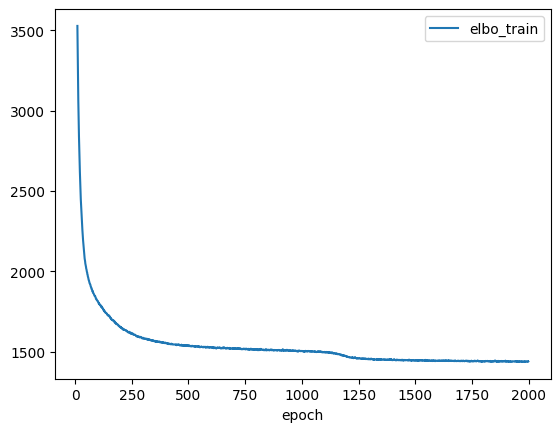

In [13]:
st_model.history["elbo_train"].iloc[10:].plot()
plt.show()

In [14]:
# st_model.history["contrastive_train"].iloc[10:].plot()
# plt.show()

提取计算的细胞类型比例

In [15]:
st_adata.obsm["proportions"] = st_model.get_proportions()

In [16]:
proportions_df = st_adata.obsm["proportions"]
proportions_df.to_csv("destvi_predicted_proportions_OneLayerGIN_64.csv", index=True)

In [17]:
st_adata.obsm["proportions"].head(5)

,endothelial cell,epithelial cell of proximal tubule,kidney collecting duct epithelial cell,kidney distal convoluted tubule epithelial cell,kidney loop of Henle epithelial cell,podocyte,immune cell,pericyte
0,0.012736,0.978745,0.000400,0.001206,0.005331,0.000263,0.001288,0.000031
1,0.035976,0.889189,0.003193,0.004847,0.007846,0.025190,0.033660,0.000099
2,0.070428,0.834216,0.002998,0.001849,0.034343,0.052100,0.003929,0.000138
3,0.131125,0.610987,0.023942,0.049105,0.054327,0.109341,0.018888,0.002284
4,0.225450,0.557936,0.004735,0.008185,0.011700,0.145666,0.046027,0.000301


可视化

In [18]:
ct_list = ["endothelial cell", "immune cell", "pericyte"]
for ct in ct_list:
    data = st_adata.obsm["proportions"][ct].values
    st_adata.obs[ct] = np.clip(data, 0, np.quantile(data, 0.99))

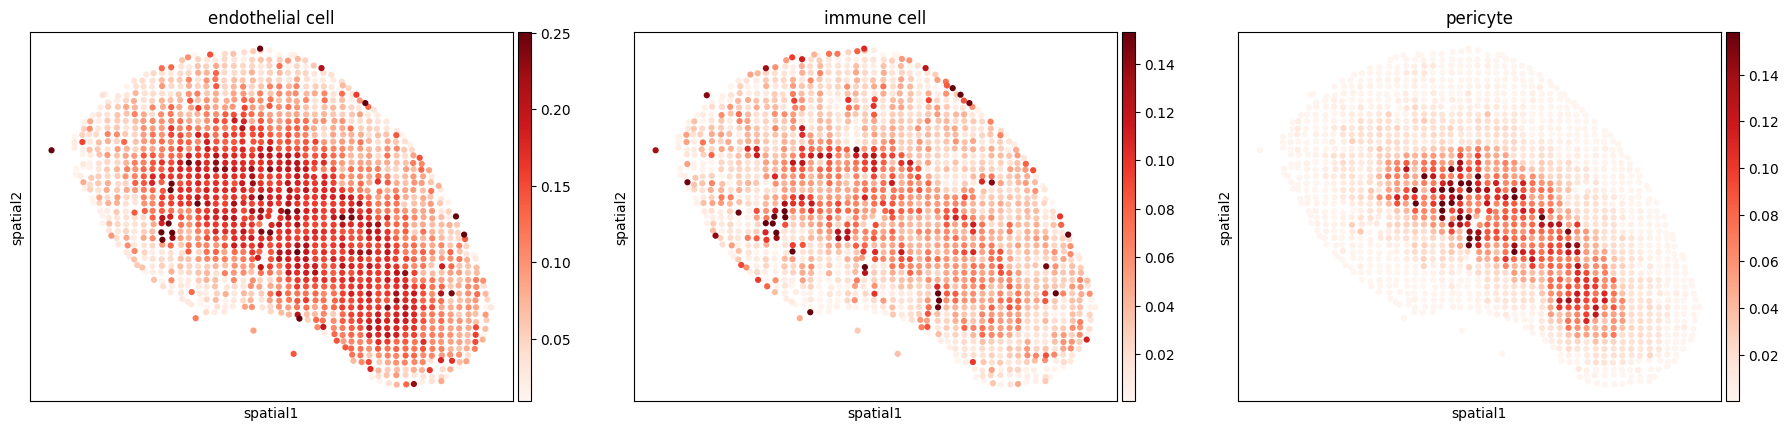

In [19]:
sc.pl.embedding(st_adata, basis="spatial", color=ct_list, cmap="Reds", s=80)

In [20]:
# 在你的 notebook 中添加这个检查
print("=== GAT 启用检查 ===")
print(f"use_gat: {st_model.module.use_gat}")
print(f"GAT layers: {len(st_model.module.gamma_gat_layers) if hasattr(st_model.module, 'gamma_gat_layers') else 'Not found'}")
print(f"Edge index shape: {st_model.module._edge_index.shape}")
print(f"X_all cached: {hasattr(st_model.module, '_X_all')}")
if hasattr(st_model.module, '_X_all'):
    print(f"X_all shape: {st_model.module._X_all.shape}")

# 测试 GAT 前向传播
try:
    test_dl = st_model._make_data_loader(adata=st_adata, batch_size=32, shuffle=False)
    test_batch = next(iter(test_dl))
    inference_outputs = st_model.module.inference()
    generative_outputs = st_model.module.generative(**st_model.module._get_generative_input(test_batch, inference_outputs))
    print("✅ GAT 前向传播成功")
    print(f"Gamma shape: {generative_outputs['gamma'].shape}")
    print(f"V shape: {generative_outputs['v'].shape}")
except Exception as e:
    print(f"❌ GAT 前向传播失败: {e}")

=== GAT 启用检查 ===
use_gat: True
GAT layers: 1
Edge index shape: torch.Size([2, 48640])
X_all cached: True
X_all shape: torch.Size([1520, 307])
✅ GAT 前向传播成功
Gamma shape: torch.Size([32, 8, 5])
V shape: torch.Size([32, 9])
